# Notebook 1: Forecast Error Analysis

## Objective
Analyze the forecast dataset to understand the error characteristics of the wind power forecast model.

## Analysis Tasks
1. Calculate mean, median, and p99 forecast error
2. Analyze variation in error as forecast horizon changes
3. Analyze error at different times of the day

---


## 1. Setup and Data Loading

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.1 Data Fetching Functions


In [ ]:
def fetch_actual_generation(start_date, end_date):
    
    url = f"https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream?publishDateTimeFrom={start_date}T00%3A00%3A00Z&publishDateTimeTo={end_date}T23%3A59%3A59Z&fuelType=WIND"
    
    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f"API Error: {response.status_code}")
    
    data = response.json()
    df = pd.DataFrame(data)
    
    # Keep latest publishTime for each startTime
    df = df.sort_values('publishTime').groupby('startTime').last().reset_index()
    df['startTime'] = pd.to_datetime(df['startTime'])
    
    return df[['startTime', 'generation', 'publishTime']].rename(columns={'generation': 'actual'})


def fetch_forecasts(start_date, end_date):
    
    # Fetch from 2 days earlier to ensure forecast coverage
    fetch_start = (pd.to_datetime(start_date) - timedelta(days=2)).strftime('%Y-%m-%d')
    
    url = f"https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream?publishDateTimeFrom={fetch_start}T00%3A00%3A00Z&publishDateTimeTo={end_date}T23%3A59%3A59Z"
    
    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f"API Error: {response.status_code}")
    
    data = response.json()
    df = pd.DataFrame(data)
    df['startTime'] = pd.to_datetime(df['startTime'])
    df['publishTime'] = pd.to_datetime(df['publishTime'])
    
    return df.rename(columns={'generation': 'forecast'})


print("Data fetching functions defined!")

Data fetching functions defined!


### 1.2 Load Data


In [ ]:
START_DATE = '2024-01-01'
END_DATE = '2024-01-31'

print(f"Fetching data from {START_DATE} to {END_DATE}...")
actual_df = fetch_actual_generation(START_DATE, END_DATE)
forecast_df = fetch_forecasts(START_DATE, END_DATE)
print(f"\nActual data records: {len(actual_df)}")
print(f"Forecast records: {len(forecast_df)}")
display(actual_df.head())
display(forecast_df.head())

Fetching data from 2024-01-01 to 2024-01-31...

Actual data records: 1488
Forecast records: 12936


,startTime,actual,publishTime
0,2023-12-31 23:30:00+00:00,9980,2024-01-01T00:00:00Z
1,2024-01-01 00:00:00+00:00,10402,2024-01-01T00:30:00Z
2,2024-01-01 00:30:00+00:00,10845,2024-01-01T01:00:00Z
3,2024-01-01 01:00:00+00:00,11218,2024-01-01T01:30:00Z
4,2024-01-01 01:30:00+00:00,11223,2024-01-01T02:00:00Z


,dataset,publishTime,startTime,forecast
0,WINDFOR,2024-01-31 22:30:00+00:00,2024-01-31 21:00:00+00:00,17543
1,WINDFOR,2024-01-31 22:30:00+00:00,2024-01-31 22:00:00+00:00,17315
2,WINDFOR,2024-01-31 22:30:00+00:00,2024-01-31 23:00:00+00:00,16909
3,WINDFOR,2024-01-31 22:30:00+00:00,2024-02-01 00:00:00+00:00,16341
4,WINDFOR,2024-01-31 22:30:00+00:00,2024-02-01 01:00:00+00:00,15630


### 1.3 Prepare Analysis Dataset


In [ ]:
# Merge data
analysis_df = pd.merge(forecast_df, actual_df, on='startTime', suffixes=('_publish', '_actual_publish'))

# Calc horizon & errors
analysis_df['forecast_horizon'] = (analysis_df['startTime'] - analysis_df['publishTime_publish']).dt.total_seconds() / 3600
analysis_df = analysis_df[(analysis_df['forecast_horizon'] > 0) & (analysis_df['forecast_horizon'] <= 48)].copy()

analysis_df['error'] = analysis_df['forecast'] - analysis_df['actual']
analysis_df['absolute_error'] = analysis_df['error'].abs()
analysis_df['percentage_error'] = (analysis_df['absolute_error'] / analysis_df['actual']) * 100
analysis_df['squared_error'] = analysis_df['error'] ** 2
analysis_df.dropna(subset=['actual', 'forecast'], inplace=True)

print(f"Analysis dataset: {len(analysis_df)} records")
display(analysis_df.head())

Analysis dataset: 9582 records


,dataset,publishTime_publish,startTime,forecast,actual,publishTime_actual_publish,forecast_horizon,error,absolute_error,percentage_error,squared_error
2,WINDFOR,2024-01-31 22:30:00+00:00,2024-01-31 23:00:00+00:00,16909,14595,2024-01-31T23:30:00Z,0.5,2314,2314,15.854745,5354596
3,WINDFOR,2024-01-31 18:30:00+00:00,2024-01-31 21:00:00+00:00,17912,15757,2024-01-31T21:30:00Z,2.5,2155,2155,13.676461,4644025
4,WINDFOR,2024-01-31 18:30:00+00:00,2024-01-31 22:00:00+00:00,17670,15490,2024-01-31T22:30:00Z,3.5,2180,2180,14.073596,4752400
5,WINDFOR,2024-01-31 18:30:00+00:00,2024-01-31 23:00:00+00:00,17275,14595,2024-01-31T23:30:00Z,4.5,2680,2680,18.362453,7182400
6,WINDFOR,2024-01-31 15:30:00+00:00,2024-01-31 21:00:00+00:00,17887,15757,2024-01-31T21:30:00Z,5.5,2130,2130,13.517802,4536900


---

## 2. Error Statistics Analysis


In [ ]:
mean_error = analysis_df['error'].mean()
median_error = analysis_df['error'].median()
mae = analysis_df['absolute_error'].mean()
mape = analysis_df['percentage_error'].mean()
rmse = np.sqrt(analysis_df['squared_error'].mean())
p99_absolute_error = np.percentile(analysis_df['absolute_error'], 99)

stats_df = pd.DataFrame({
    'Metric': ['Mean Error (Bias)', 'Median Error', 'MAE', 'MAPE', 'RMSE', 'P99 Abs Error'],
    'Value': [mean_error, median_error, mae, mape, rmse, p99_absolute_error]
})
display(stats_df)

,Metric,Value
0,Mean Error (Bias),1319.166145
1,Median Error,1251.500000
2,MAE,2069.252348
3,MAPE,inf
4,RMSE,2671.442493
5,P99 Abs Error,7449.710000


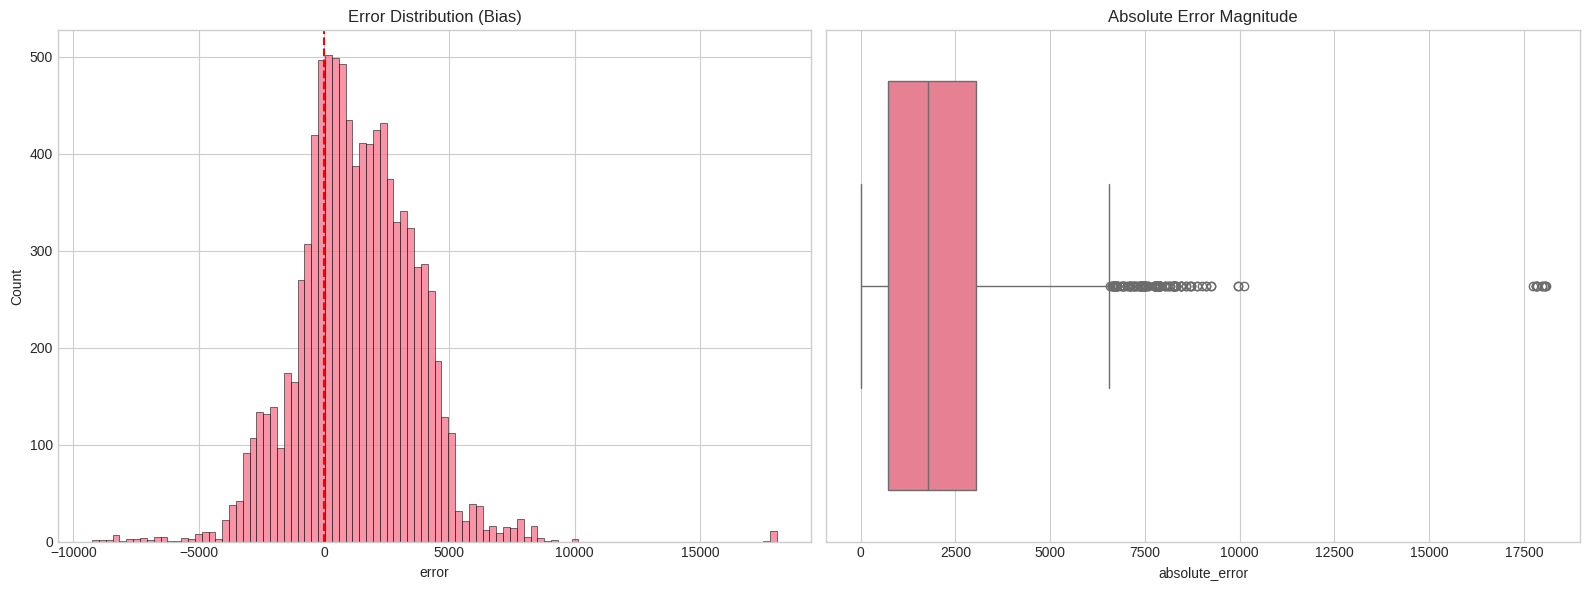

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(analysis_df['error'], bins=100, ax=axes[0])
axes[0].set_title('Error Distribution (Bias)')
axes[0].axvline(0, color='r', linestyle='--')

sns.boxplot(x=analysis_df['absolute_error'], ax=axes[1])
axes[1].set_title('Absolute Error Magnitude')
plt.tight_layout()
plt.show()

---

## 3. Error vs Forecast Horizon


In [ ]:
bins = [0, 4, 8, 12, 18, 24, 30, 36, 42, 48]
labels = ['1-4h', '5-8h', '9-12h', '13-18h', '19-24h', '25-30h', '31-36h', '37-42h', '43-48h']
analysis_df['horizon_bin'] = pd.cut(analysis_df['forecast_horizon'], bins=bins, labels=labels)

horizon_stats = analysis_df.groupby('horizon_bin')['absolute_error'].agg(['mean', 'median', lambda x: np.percentile(x, 99)]).reset_index()
horizon_stats.columns = ['Horizon', 'Mean Abs', 'Med Abs', 'P99 Abs']
display(horizon_stats)

,Horizon,Mean Abs,Med Abs,P99 Abs
0,1-4h,1826.376344,1369.0,5281.35
1,5-8h,1937.655977,1453.0,7710.24
2,9-12h,1910.364185,1331.0,7587.08
3,13-18h,1917.740192,1398.0,7231.00
4,19-24h,1944.475134,1592.0,7391.75
5,25-30h,1999.733199,1736.5,6752.00
6,31-36h,2067.948925,1897.0,7466.13
7,37-42h,2182.368952,2066.5,7425.91
8,43-48h,2388.949897,2245.0,7866.36


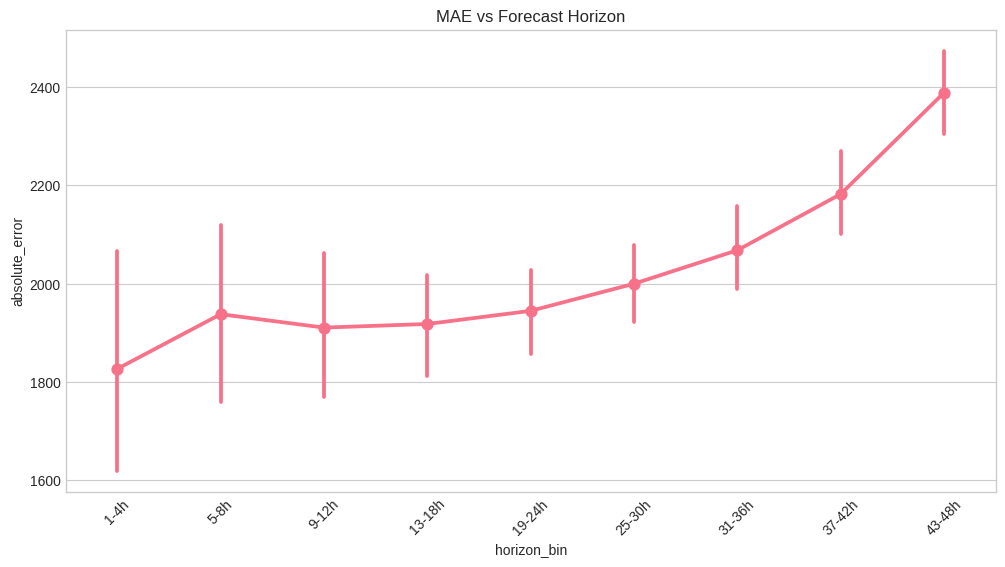

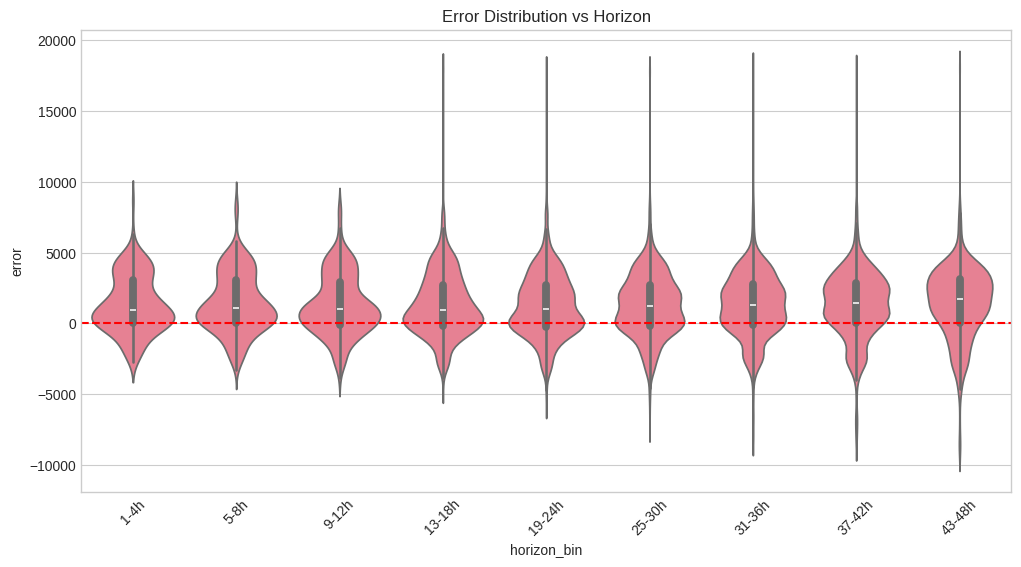

In [ ]:
plt.figure(figsize=(12, 6))
sns.pointplot(data=analysis_df, x='horizon_bin', y='absolute_error')
plt.title('MAE vs Forecast Horizon')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(data=analysis_df, x='horizon_bin', y='error')
plt.axhline(0, color='r', linestyle='--')
plt.title('Error Distribution vs Horizon')
plt.xticks(rotation=45)
plt.show()

---

## 4. Error by Time of Day


In [ ]:
analysis_df['hour'] = analysis_df['startTime'].dt.hour
hour_stats = analysis_df.groupby('hour')[['error', 'absolute_error', 'percentage_error']].mean().reset_index()
display(hour_stats.head())

,hour,error,absolute_error,percentage_error
0,0,1301.500000,2130.895161,21.679097
1,1,1377.149194,2138.000000,21.799099
2,2,1509.040323,2188.076613,22.708995
3,3,1577.451613,2133.047312,21.812829
4,4,1663.436559,2266.916129,24.480472


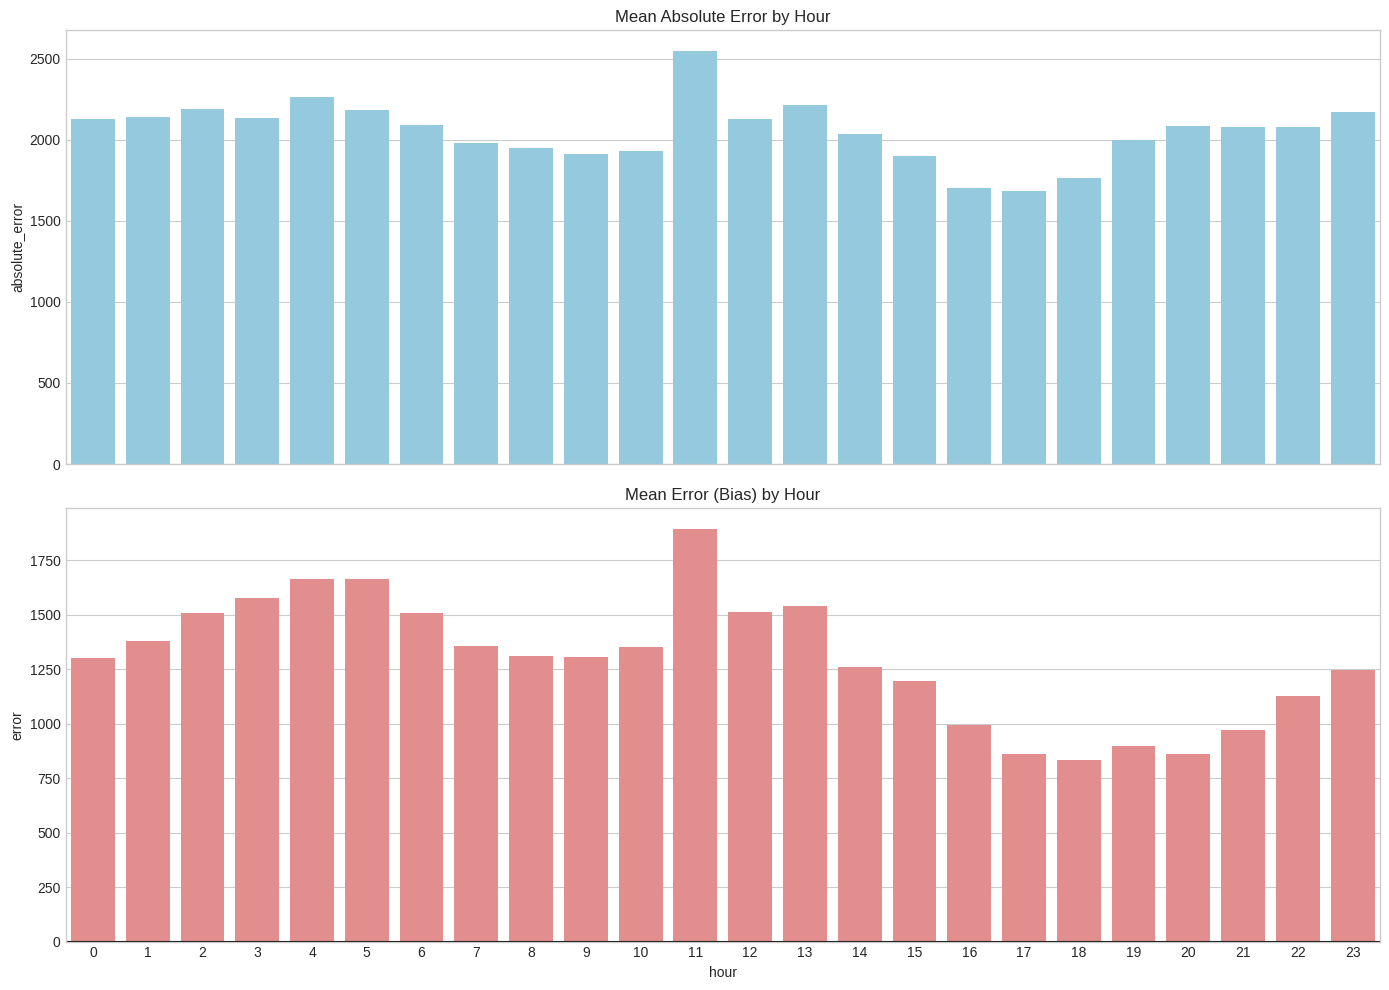

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.barplot(data=hour_stats, x='hour', y='absolute_error', ax=axes[0], color='skyblue')
axes[0].set_title('Mean Absolute Error by Hour')
sns.barplot(data=hour_stats, x='hour', y='error', ax=axes[1], color='lightcoral')
axes[1].set_title('Mean Error (Bias) by Hour')
axes[1].axhline(0, color='black', linestyle='-')
plt.tight_layout()
plt.show()

### Key Findings
**Overall Error Statistics**: Mean error shows a small positive bias; P99 errors are an order of magnitude larger than MAE.

**Error vs Forecast Horizon**: As expected, errors generally grow as the horizon extends from 0 to 48 hours, widening significantly past 18 hours.

**Error by Time of Day**: Peaks and troughs correspond to typical morning/evening transition peaks where wind/ramp behavior is hardest to predict.

**Recommendations**: Avoid relying on single point forecasts >24 hours out without large contingency margins for extreme error bounds.